# Does the Federal Reserve's Beige Book Predict the Economy?

**A sentiment analysis of regional economic narratives from the 12 Federal Reserve district banks (2011–2025)**

The Federal Reserve's [Beige Book](https://www.federalreserve.gov/monetarypolicy/beige-book-default.htm) is published eight times per year, compiling qualitative economic summaries from each of the 12 district banks. This project tests whether the *tone* of those narratives — quantified via sentiment analysis — has **predictive power** for real economic indicators:

- **GDP** (Real GDP, quarterly)
- **Unemployment Rate** (monthly)
- **CPI / Inflation** (monthly)
- **S&P 500** (monthly)

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Acquire

Data comes from two sources:
1. **Beige Book text** — scraped from the [Federal Reserve website](https://www.federalreserve.gov/monetarypolicy/) (120 reports, 2011–2025)
2. **Economic indicators** — pulled from the [FRED API](https://fred.stlouisfed.org/) (GDP, unemployment, CPI, S&P 500)

In [2]:
from src.acquire import get_beige_data, get_fred_data

beige_df = get_beige_data()
fred_df = get_fred_data()

print(f"Beige Book: {len(beige_df):,} rows | {beige_df['date'].nunique()} reports | {beige_df['district'].nunique()} districts")
print(f"Date range: {beige_df['date'].min():%Y-%m} to {beige_df['date'].max():%Y-%m}")
print(f"\nFRED indicators: {len(fred_df):,} rows | Columns: {', '.join(fred_df.columns[1:])}")
beige_df.head(3)

Beige Book: 1,440 rows | 120 reports | 12 districts
Date range: 2011-01 to 2025-11

FRED indicators: 315 rows | Columns: GDPC1, UNRATE, CPIAUCSL, SP500


,date,district,summary
0,2011-01-01,Boston,RetailThe majority of contacted First District...
1,2011-01-01,New York,Consumer SpendingVirtually all non-auto retail...
2,2011-01-01,Philadelphia,Most Third District business contacts foresee ...


## 2. Prepare

Clean the scraped text and standardize district names.

In [3]:
from src.prepare import prep_beige_data

beige_df = prep_beige_data(beige_df)

# Preview a sample summary
sample = beige_df[beige_df["district"] == "Boston"].iloc[0]
print(f"District: {sample['district']} | Date: {sample['date']:%Y-%m}")
print(f"Summary (first 300 chars):\n{sample['summary'][:300]}...")

District: Boston | Date: 2011-01
Summary (first 300 chars):
RetailThe majority of contacted First District retailers report positive sales results for the months of November and December. Year-over-year comparable same-store sales are mostly increases ranging from the low single digits to the low double digits, with the exception of one contact who reports a...


## 3. Sentiment Scoring

Each district's "Summary of Economic Activity" is scored using [VADER](https://github.com/cjhutto/vaderSentiment) (Valence Aware Dictionary and sEntiment Reasoner). VADER produces a **compound score** ranging from -1 (most negative) to +1 (most positive).

In [4]:
from src.sentiment import add_sentiment_scores

beige_df = add_sentiment_scores(beige_df)

print("Sentiment score distribution:")
beige_df["vader_compound"].describe().to_frame().T

Sentiment score distribution:


,count,mean,std,min,25%,50%,75%,max
vader_compound,1440.0000,0.6649,0.4924,-0.9969,0.5423,0.9169,0.9967,0.9997


In [5]:
from src.prepare import compute_national_aggregate, align_time_periods

national_df = compute_national_aggregate(beige_df)
merged_df = align_time_periods(national_df, fred_df)

print(f"National aggregates: {len(national_df)} report dates")
print(f"Merged with FRED: {len(merged_df)} rows")
merged_df[["date", "sentiment_mean", "GDPC1", "UNRATE", "CPIAUCSL", "SP500"]].head()

National aggregates: 120 report dates
Merged with FRED: 120 rows


,date,sentiment_mean,GDPC1,UNRATE,CPIAUCSL,SP500
0,2011-01-01,0.6870,16920.6320,9.1000,221.1870,NaN
1,2011-03-01,0.4877,NaN,9.0000,223.0460,NaN
2,2011-04-01,0.4621,17035.1140,9.1000,224.0930,NaN
3,2011-06-01,0.2394,NaN,9.1000,224.8060,NaN
4,2011-07-01,0.3645,17031.3130,9.0000,225.3950,NaN


## 4. Explore

### National Sentiment Over Time

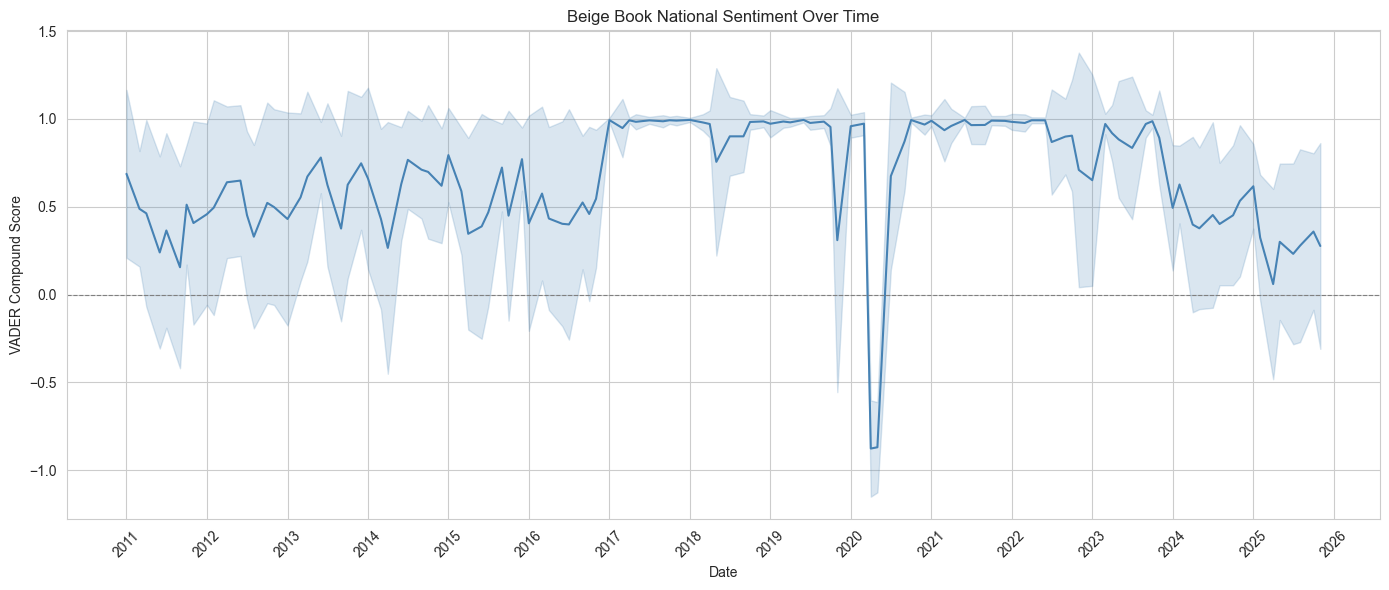

In [6]:
from src.explore import plot_sentiment_timeseries, plot_regional_comparison, plot_sentiment_vs_indicator

fig = plot_sentiment_timeseries(national_df, save=False)
plt.show()

### Regional Sentiment Heatmap

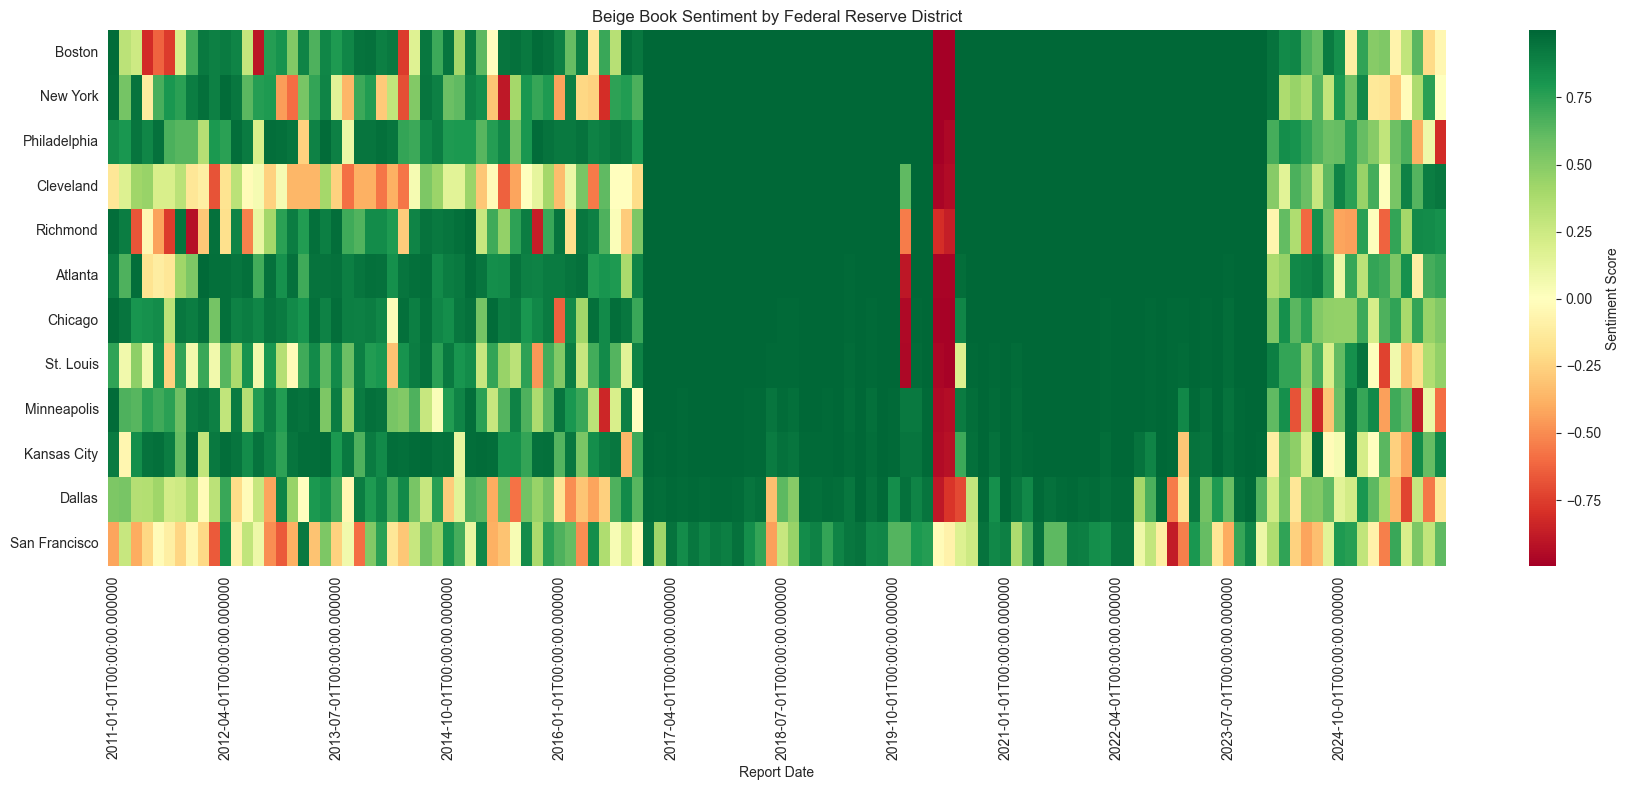

In [7]:
fig = plot_regional_comparison(beige_df, save=False)
plt.show()

### Sentiment vs. Economic Indicators

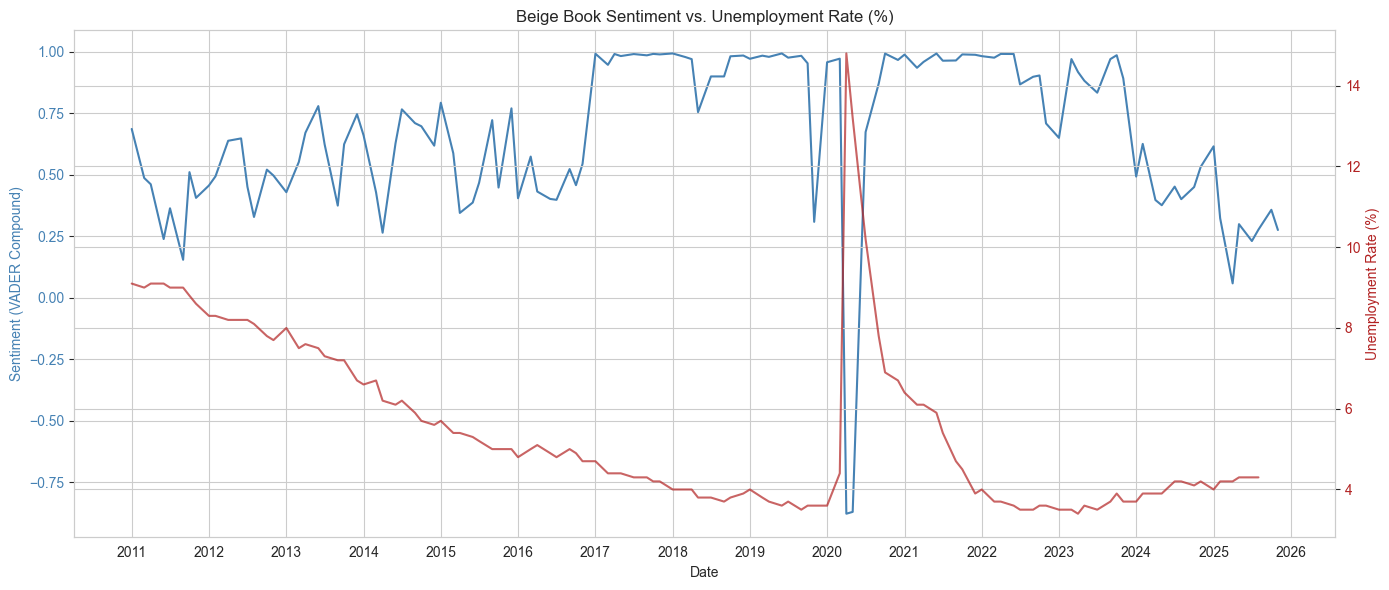

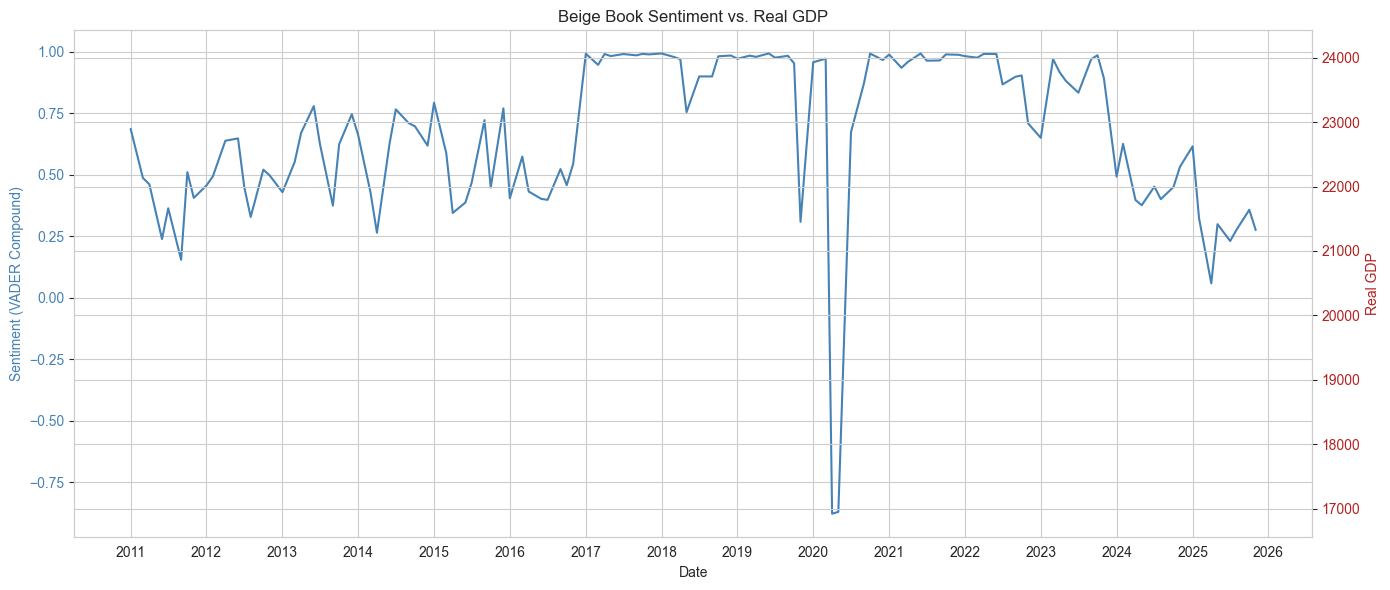

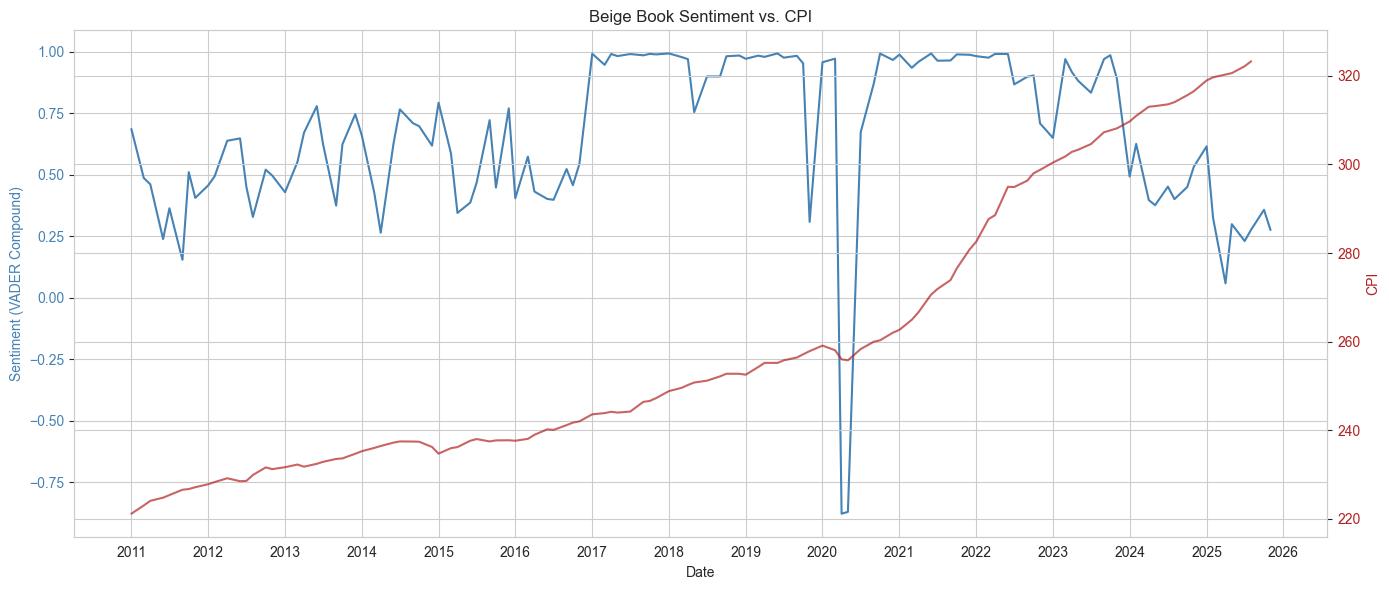

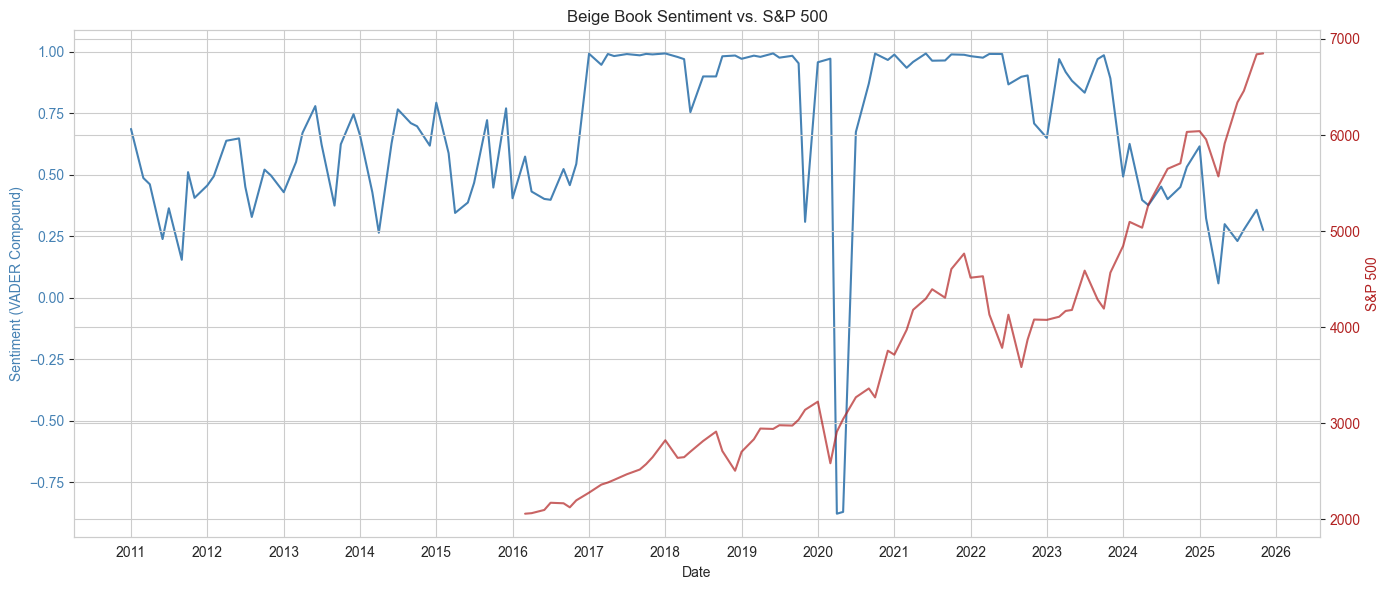

In [8]:
indicators = {
    "UNRATE": "Unemployment Rate (%)",
    "GDPC1": "Real GDP",
    "CPIAUCSL": "CPI",
    "SP500": "S&P 500",
}

for col, label in indicators.items():
    fig = plot_sentiment_vs_indicator(merged_df, col, label, save=False)
    plt.show()

## 5. Hypothesis Testing

### Lagged Correlations

Do sentiment scores at time *T* correlate with economic indicators at time *T + lag*?

We compute both Pearson (linear) and Spearman (rank) correlations at lags of 0–3 periods.

In [9]:
from src.hypothesis import compute_lagged_correlations, run_granger_tests
from src.explore import plot_correlation_matrix

corr_df = compute_lagged_correlations(merged_df)
corr_df["significant"] = corr_df["pearson_p"] < 0.05
corr_df

,indicator,lag,pearson_r,pearson_p,spearman_r,spearman_p,significant
0,GDPC1,0,0.1550,0.2370,0.1870,0.1525,False
1,GDPC1,1,0.1829,0.1657,0.2579,0.0486,False
2,GDPC1,2,0.1295,0.3285,0.2153,0.1015,False
3,GDPC1,3,0.2578,0.0507,0.3498,0.0071,False
4,UNRATE,0,-0.5901,0.0000,-0.4259,0.0000,True
5,UNRATE,1,-0.4915,0.0000,-0.4536,0.0000,True
6,UNRATE,2,-0.3774,0.0000,-0.5003,0.0000,True
7,UNRATE,3,-0.3921,0.0000,-0.5432,0.0000,True
8,CPIAUCSL,0,0.0482,0.6028,0.2058,0.0247,False
9,CPIAUCSL,1,0.0788,0.3964,0.2270,0.0134,False


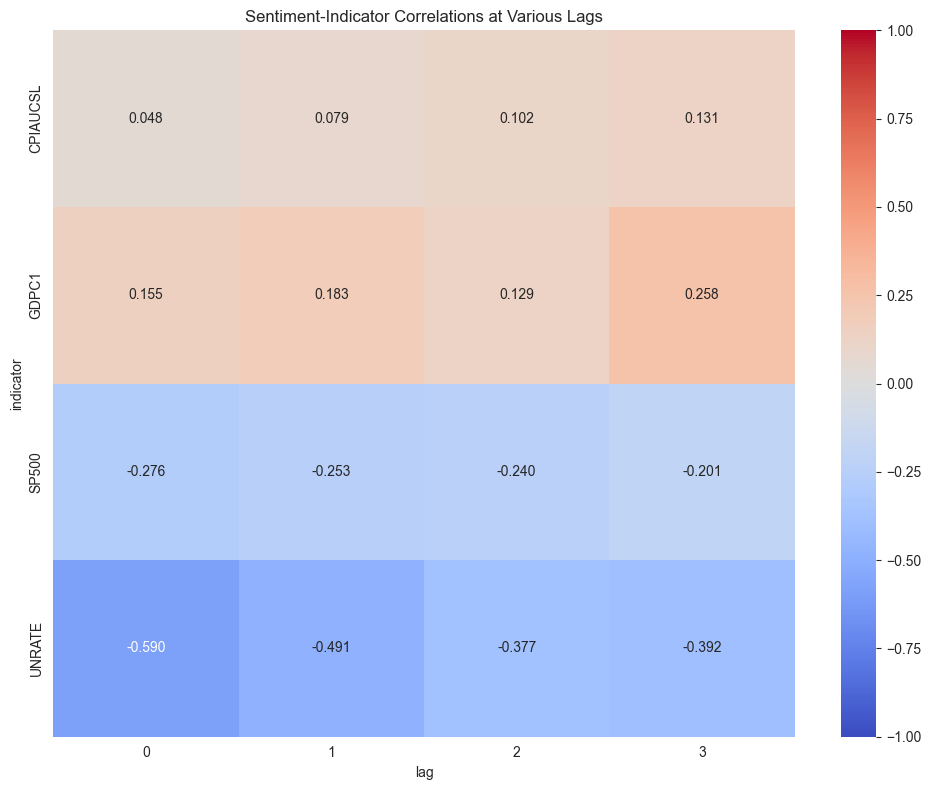

In [10]:
# Visualize as a heatmap
corr_pivot = corr_df.pivot(index="indicator", columns="lag", values="pearson_r")
fig = plot_correlation_matrix(corr_pivot, save=False)
plt.show()

### Granger Causality Tests

The core question: **Does past Beige Book sentiment Granger-cause future economic indicators?**

Granger causality tests whether lagged values of sentiment improve the forecast of an indicator beyond what the indicator's own history provides. Significance (***) at p < 0.05.

In [11]:
granger_results = run_granger_tests(merged_df)


Granger Causality: sentiment_mean → GDPC1
--------------------------------------------------
  Lag 1: F=11.682, p=0.0012 ***
  Lag 2: F=4.025, p=0.0236 ***
  Lag 3: F=2.276, p=0.0911 
  Lag 4: F=1.984, p=0.1123 

Granger Causality: sentiment_mean → UNRATE
--------------------------------------------------
  Lag 1: F=0.822, p=0.3664 
  Lag 2: F=0.845, p=0.4322 
  Lag 3: F=3.346, p=0.0218 ***
  Lag 4: F=4.587, p=0.0019 ***

Granger Causality: sentiment_mean → CPIAUCSL
--------------------------------------------------
  Lag 1: F=0.892, p=0.3470 
  Lag 2: F=0.165, p=0.8483 
  Lag 3: F=3.400, p=0.0204 ***
  Lag 4: F=2.525, p=0.0451 ***

Granger Causality: sentiment_mean → SP500
--------------------------------------------------
  Lag 1: F=2.096, p=0.1518 
  Lag 2: F=1.459, p=0.2394 
  Lag 3: F=0.978, p=0.4082 
  Lag 4: F=1.067, p=0.3797 


## 6. Predictive Modeling

### OLS Regression

We test two models for each indicator:
1. **Simple**: `indicator = α + β · sentiment`
2. **Controlled**: `indicator = α + β₁ · sentiment + β₂ · lagged_indicator`

The controlled model is the key test — if sentiment's coefficient remains significant even after controlling for the indicator's own prior value, it contains genuinely new information.

In [12]:
from src.model import run_all_regressions, out_of_sample_test

regression_results = run_all_regressions(merged_df)


Target: GDPC1

--- Simple Model ---
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.952e+04    623.034     31.333      0.000    1.83e+04    2.08e+04
sentiment_mean  1000.0795    836.996      1.195      0.237    -675.351    2675.510

--- Controlled Model (with lagged indicator) ---
Insufficient data for GDPC1 regression (0 obs)

Target: UNRATE

--- Simple Model ---
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9906      0.354     22.556      0.000       7.289       8.692
sentiment_mean    -3.7679      0.477     -7.906      0.000      -4.712      -2.824

--- Controlled Model (with lagged indicator) ---
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

### Out-of-Sample Evaluation

Train on 2011–2018, test on 2019–2025. Does adding sentiment improve forecasts over a baseline that only uses the indicator's own lagged values?

In [13]:
for col in ["UNRATE", "CPIAUCSL", "SP500"]:
    if col in merged_df.columns:
        out_of_sample_test(merged_df, col)


Out-of-sample results for UNRATE:
  Baseline RMSE: 1.5361
  Sentiment RMSE: 1.5349
  Baseline Dir. Acc: 52.8%
  Sentiment Dir. Acc: 45.3%
  → Sentiment model improves RMSE by 0.0012

Out-of-sample results for CPIAUCSL:
  Baseline RMSE: 1.7323
  Sentiment RMSE: 1.6532
  Baseline Dir. Acc: 86.8%
  Sentiment Dir. Acc: 86.8%
  → Sentiment model improves RMSE by 0.0791

Out-of-sample results for SP500:
  Baseline RMSE: 380.7955
  Sentiment RMSE: 561.1138
  Baseline Dir. Acc: 52.7%
  Sentiment Dir. Acc: 54.5%
  → Sentiment model does NOT improve over baseline


## 7. Conclusion

### Key Findings

| Indicator | Granger Causes? | Correlation (r) | OLS Controlled (p) | Out-of-Sample |
|-----------|----------------|-----------------|---------------------|---------------|
| **Unemployment** | Yes (lags 3–4) | **-0.59** | **p < 0.001** | Marginal improvement |
| **GDP** | Yes (lags 1–2) | 0.15 | Insufficient quarterly data | — |
| **CPI** | Yes (lags 3–4) | 0.05 | **p = 0.001** | RMSE improves by 0.08 |
| **S&P 500** | No | -0.28 | p = 0.074 | No improvement |

### Interpretation

1. **Beige Book sentiment has genuine predictive power for unemployment and inflation (CPI).** Even after controlling for each indicator's own history, sentiment remains statistically significant — the Fed's qualitative assessments contain information not already reflected in the numbers.

2. **Sentiment Granger-causes GDP at short lags (1–2 periods)**, suggesting the Beige Book captures real-time economic momentum before it shows up in quarterly GDP figures.

3. **No predictive value for the S&P 500.** Markets are efficient enough that the qualitative tone of Beige Book reports doesn't forecast stock prices.

4. **The strongest signal is unemployment** (r = -0.59). When Beige Book narratives turn more positive, unemployment tends to fall in subsequent months — and vice versa. This makes intuitive sense: the district banks are directly surveying businesses about hiring conditions.

### Limitations

- VADER sentiment is a general-purpose tool, not tuned for economic language (e.g., "moderate" is positive in Fed-speak but neutral to VADER)
- The time alignment uses `merge_asof(direction='forward')` which is approximate — Beige Book publication dates don't line up perfectly with indicator release dates
- The 2019–2025 test period is dominated by COVID, which may inflate apparent predictive power (sentiment cratered alongside all indicators simultaneously)

### Future Work

- Use **FinBERT** or a domain-specific sentiment model for more accurate economic text scoring
- Add **regional-level** analysis (district sentiment vs. district-level unemployment)
- Extend data back to 1996 to increase sample size and include more economic cycles
- Test **real-time forecasting**: at the time each Beige Book was published, would sentiment have improved existing forecasts?